# **AI Financial Market Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'ai_financial_market_daily_realistic_synthetic_dataset.csv')
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [4]:
data["Date"] = pd.to_datetime(data["Date"])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [6]:
data["Company"].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [7]:
data["Year"] = data["Date"].dt.year

In [8]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [9]:
data.isnull().sum()

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
Year                       0
dtype: int64

# Questions

1. How much **R&D spending** was done by each company?  


In [10]:
RD_Group_sum = data.groupby("Company")["R&D_Spending_USD_Mn"].sum()/1000
RD_Group_sum

Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

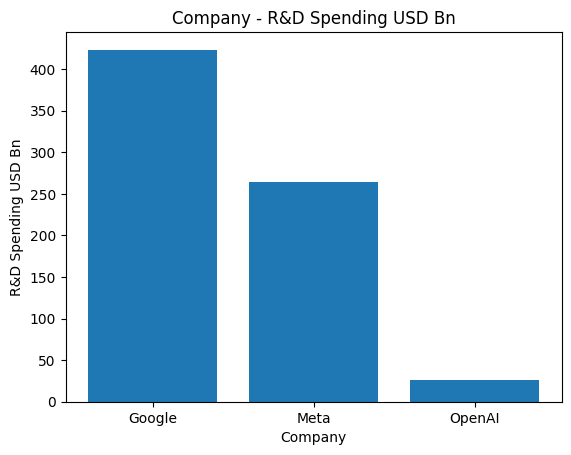

In [11]:
plt.bar(RD_Group_sum.index, RD_Group_sum.values)
plt.xlabel("Company")
plt.ylabel("R&D Spending USD Bn")
plt.title("Company - R&D Spending USD Bn")
plt.savefig("Figures/company_r&d_spending_usd.png")
plt.show()

2. How much **AI revenue** was earned by each company?  


In [12]:
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%', 'Year'],
      dtype='object')

In [13]:
AI_Group_sum = data.groupby("Company")["AI_Revenue_USD_Mn"].sum()/1000
AI_Group_sum

Company
Google    284.49838
Meta      189.62182
OpenAI      9.46289
Name: AI_Revenue_USD_Mn, dtype: float64

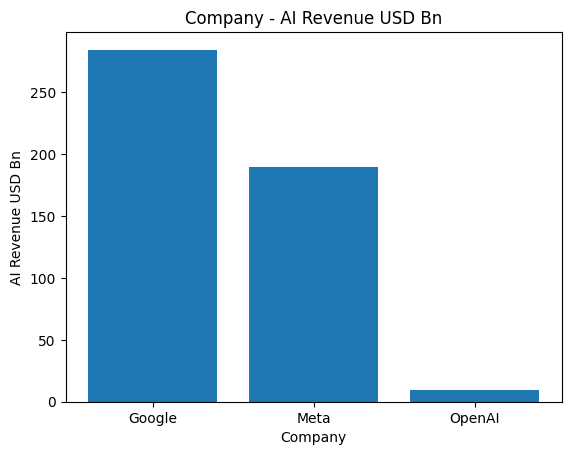

In [14]:
plt.bar(AI_Group_sum.index, AI_Group_sum.values)
plt.xlabel("Company")
plt.ylabel("AI Revenue USD Bn")
plt.title("Company - AI Revenue USD Bn")
plt.savefig("Figures/company_ai_revenue_usd.png")
plt.show()

3. What was the **date-wise impact on stock** performance?  


In [15]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


4. Identify **events with maximum stock impact**.  


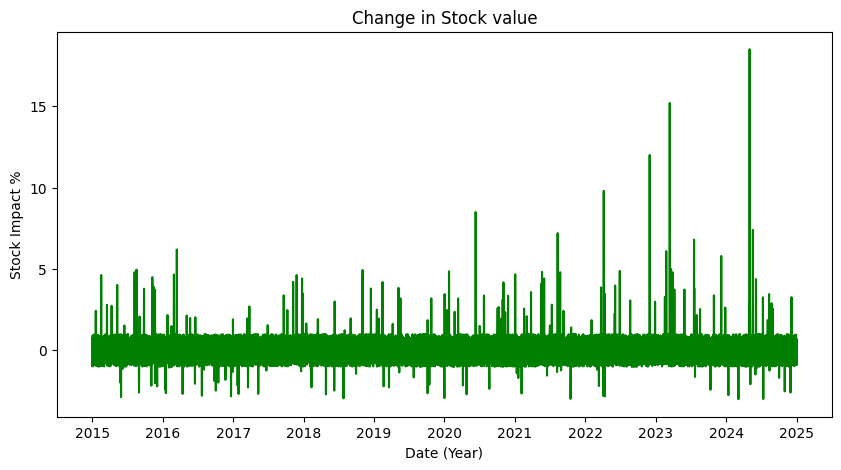

In [16]:
plt.figure(figsize=(10,5))
plt.plot(data["Date"],data["Stock_Impact_%"],color="green")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value")
plt.savefig("Figures/Stock_impact.png")
plt.show()

In [17]:
data["Company"].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [18]:
data_openAI = data[data["Company"]=="OpenAI"]
data_Google = data[data["Company"]=="Google"]
data_Meta = data[data["Company"]=="Meta"]

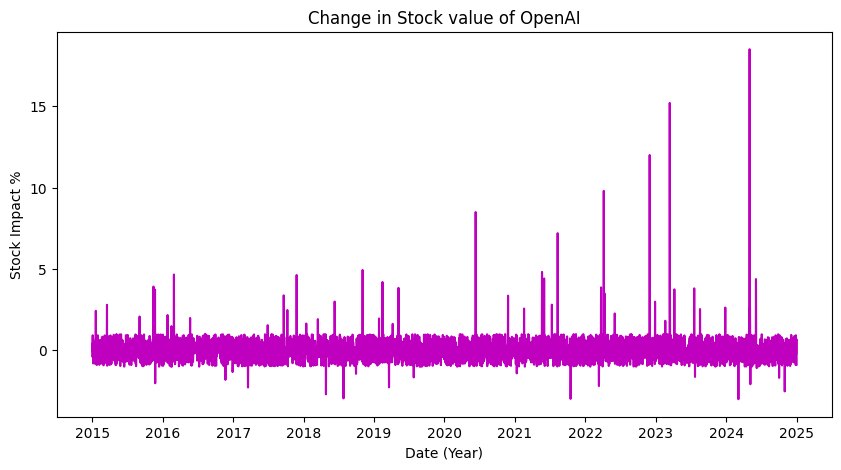

In [19]:
plt.figure(figsize=(10,5))
plt.plot(data_openAI["Date"],data_openAI["Stock_Impact_%"],color="m")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value of OpenAI")
plt.savefig("Figures/Stock_impact_OpenAI.png")
plt.show()

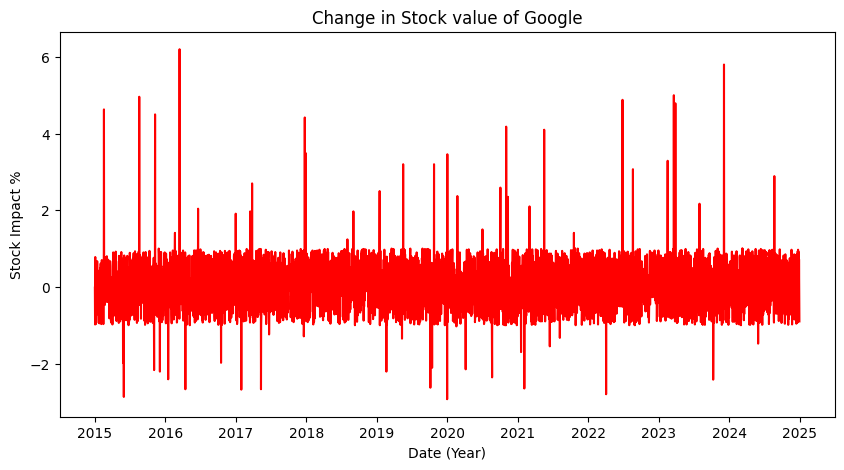

In [20]:
plt.figure(figsize=(10,5))
plt.plot(data_Google["Date"],data_Google["Stock_Impact_%"],color="r")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value of Google")
plt.savefig("Figures/Stock_impact_Google.png")
plt.show()

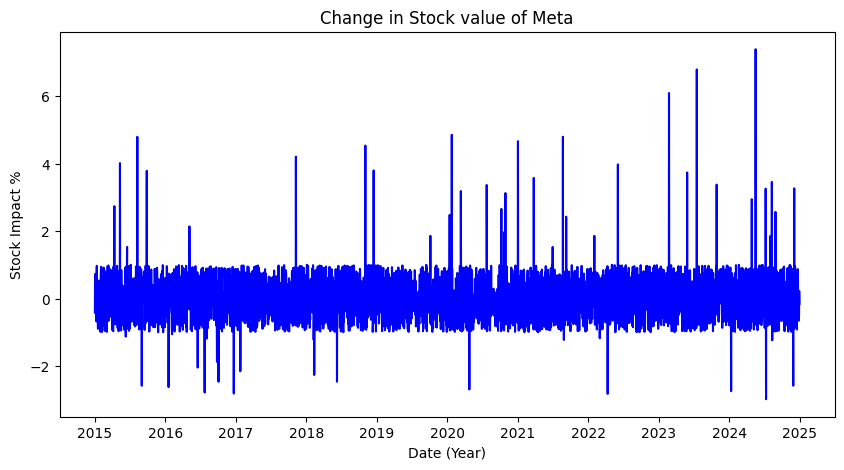

In [21]:
plt.figure(figsize=(10,5))
plt.plot(data_Meta["Date"],data_Meta["Stock_Impact_%"],color="b")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value of Meta")
plt.savefig("Figures/Stock_impact_Meta.png")
plt.show()

In [22]:
data_openAI[["Date","Event","Stock_Impact_%"]].sort_values(by="Stock_Impact_%", ascending=False).head(1)

,Date,Event,Stock_Impact_%
3408,2024-05-01,GPT-5 release (predicted),18.5


In [23]:
data_Google[["Date","Event","Stock_Impact_%"]].sort_values(by="Stock_Impact_%", ascending=False).head(1)

,Date,Event,Stock_Impact_%
4092,2016-03-15,AlphaGo beats Lee Sedol,6.2


In [24]:
data_Meta[["Date","Event","Stock_Impact_%"]].sort_values(by="Stock_Impact_%", ascending=False).head(1)

,Date,Event,Stock_Impact_%
10731,2024-05-18,LLaMA 3 release (predicted),7.4


5. Analyze **AI revenue growth trends** for each company.  


In [25]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


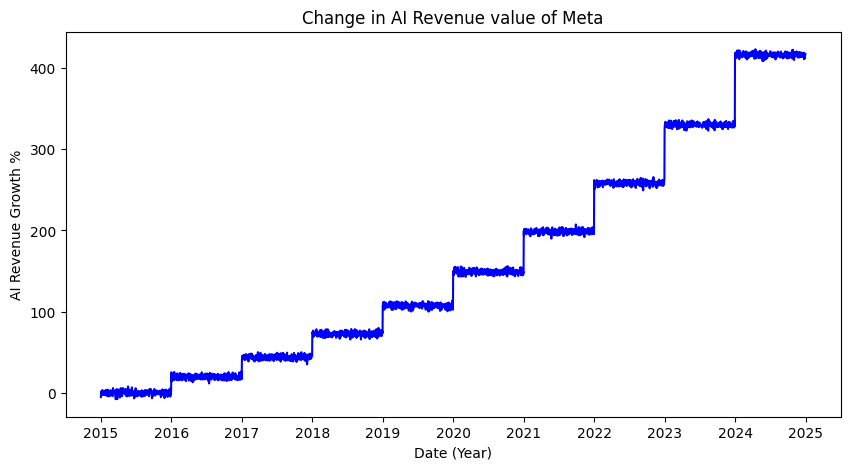

In [26]:
plt.figure(figsize=(10,5))
plt.plot(data_Meta["Date"],data_Meta["AI_Revenue_Growth_%"],color="b")
plt.xlabel("Date (Year)")
plt.ylabel("AI Revenue Growth %")
plt.title("Change in AI Revenue value of Meta")
plt.savefig("Figures/AI_Revenue_Meta.png")
plt.show()

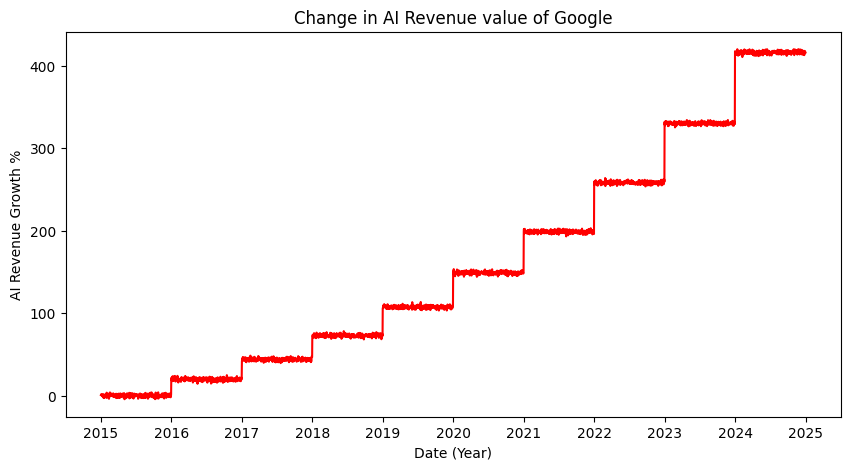

In [27]:
plt.figure(figsize=(10,5))
plt.plot(data_Google["Date"],data_Google["AI_Revenue_Growth_%"],color="r")
plt.xlabel("Date (Year)")
plt.ylabel("AI Revenue Growth %")
plt.title("Change in AI Revenue value of Google")
plt.savefig("Figures/AI_Revenue_Google.png")
plt.show()

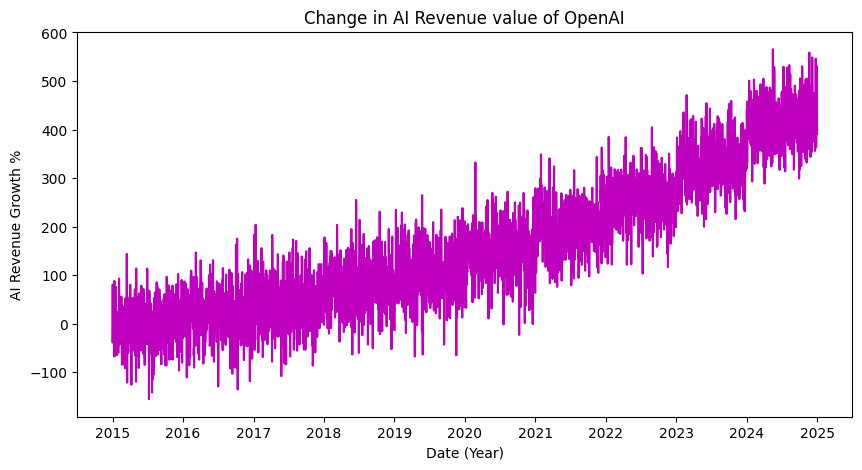

In [28]:
plt.figure(figsize=(10,5))
plt.plot(data_openAI["Date"],data_openAI["AI_Revenue_Growth_%"],color="m")
plt.xlabel("Date (Year)")
plt.ylabel("AI Revenue Growth %")
plt.title("Change in AI Revenue value of OpenAI")
plt.savefig("Figures/AI_Revenue_OpenAI.png")
plt.show()

<Axes: xlabel='Date', ylabel='AI_Revenue_Growth_%'>

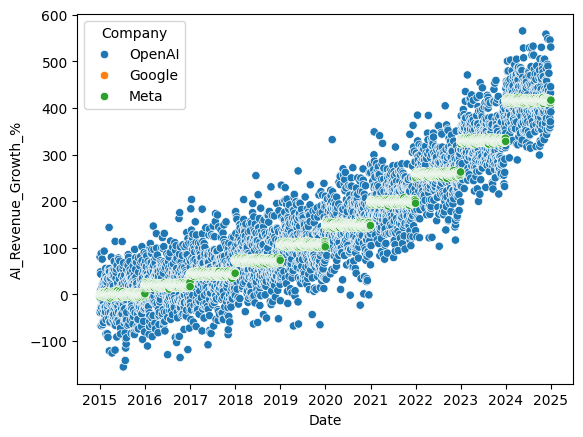

In [29]:
sns.scatterplot(x="Date",y="AI_Revenue_Growth_%",data=data,hue="Company")

6. Compute **correlations** between columns.  


In [30]:
data.corr(numeric_only=True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.297701
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.526478
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.952199
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.016525
Year,0.297701,0.526478,0.952199,0.016525,1.000000


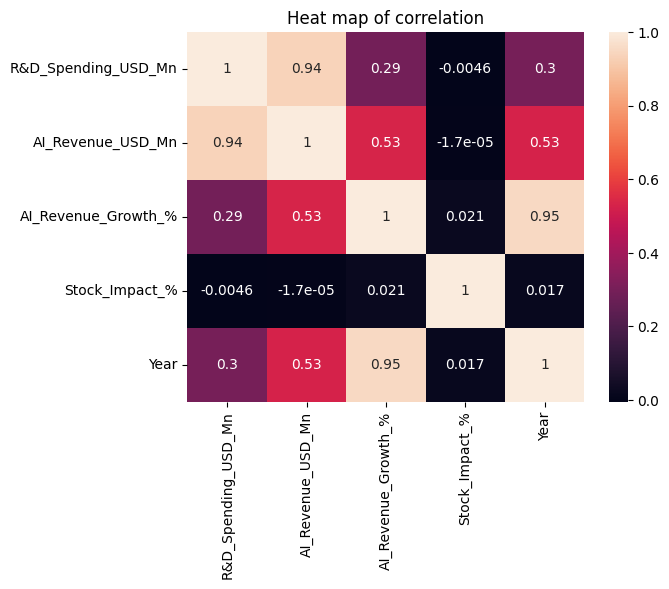

In [35]:
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.title("Heat map of correlation")
plt.savefig("Figures/Correlation.png")
plt.show()

7. Compare **yearly expenditure vs revenue**.  


In [36]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [39]:
spend = data.groupby("Year")["R&D_Spending_USD_Mn"].sum()
spend

Year
2015    49304.23
2016    53349.94
2017    57475.12
2018    62002.16
2019    67071.51
2020    72602.53
2021    78207.32
2022    84390.17
2023    91193.92
2024    98760.08
Name: R&D_Spending_USD_Mn, dtype: float64

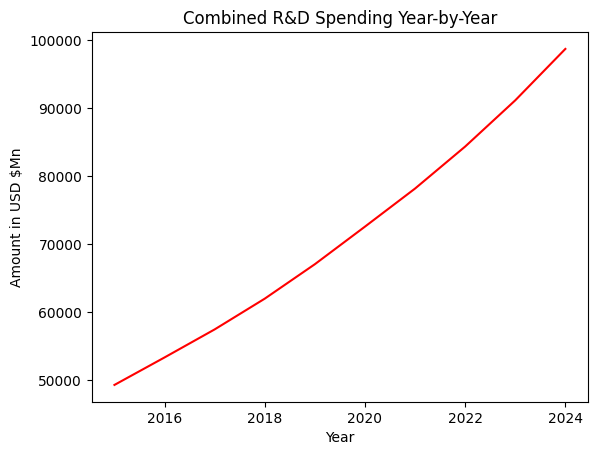

In [41]:
plt.plot(spend.index, spend.values,c='r')
plt.title('Combined R&D Spending Year-by-Year')
plt.xlabel("Year")
plt.ylabel("Amount in USD $Mn")
plt.savefig("Figures/R&D_spending_year_by_year.png")
plt.show()

In [43]:
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%', 'Year'],
      dtype='object')

In [44]:
revenue = data.groupby("Year")["AI_Revenue_USD_Mn"].sum()
revenue

Year
2015    18623.21
2016    22361.20
2017    26776.80
2018    32164.44
2019    38580.32
2020    46456.19
2021    55591.14
2022    66674.24
2023    80041.64
2024    96313.91
Name: AI_Revenue_USD_Mn, dtype: float64

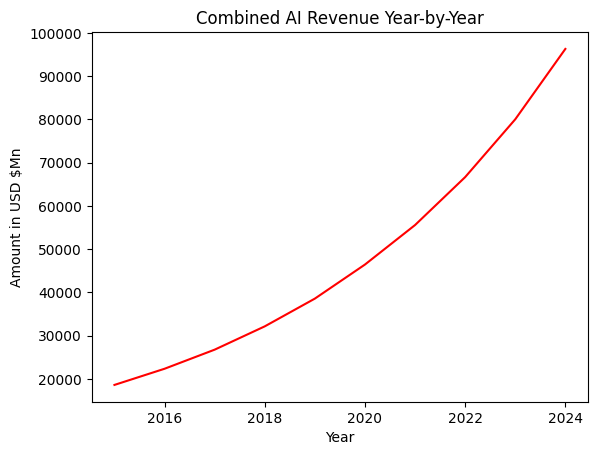

In [45]:
plt.plot(revenue.index, revenue.values,c='r')
plt.title('Combined AI Revenue Year-by-Year')
plt.xlabel("Year")
plt.ylabel("Amount in USD $Mn")
plt.savefig("Figures/Combined_AI_Revenue_year_by_year.png")
plt.show()

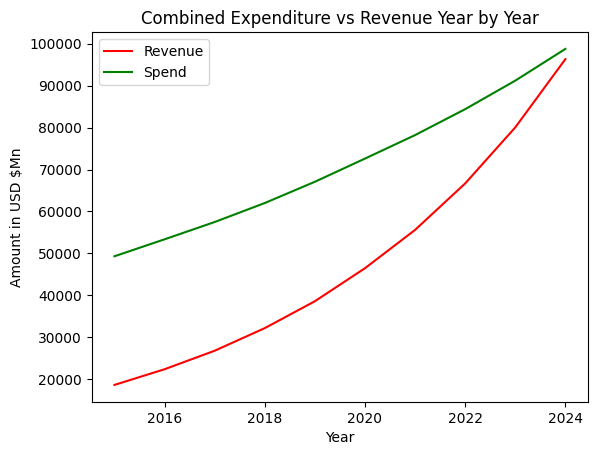

In [48]:
plt.plot(revenue.index, revenue.values,c='r',label='Revenue')
plt.plot(spend.index, spend.values,c='g',label="Spend")
plt.title('Combined Expenditure vs Revenue Year by Year')
plt.xlabel("Year")
plt.ylabel("Amount in USD $Mn")
plt.savefig("Figures/Combined_expenditure_vs_Revenue_year_by_year.png")
plt.legend()
plt.show()

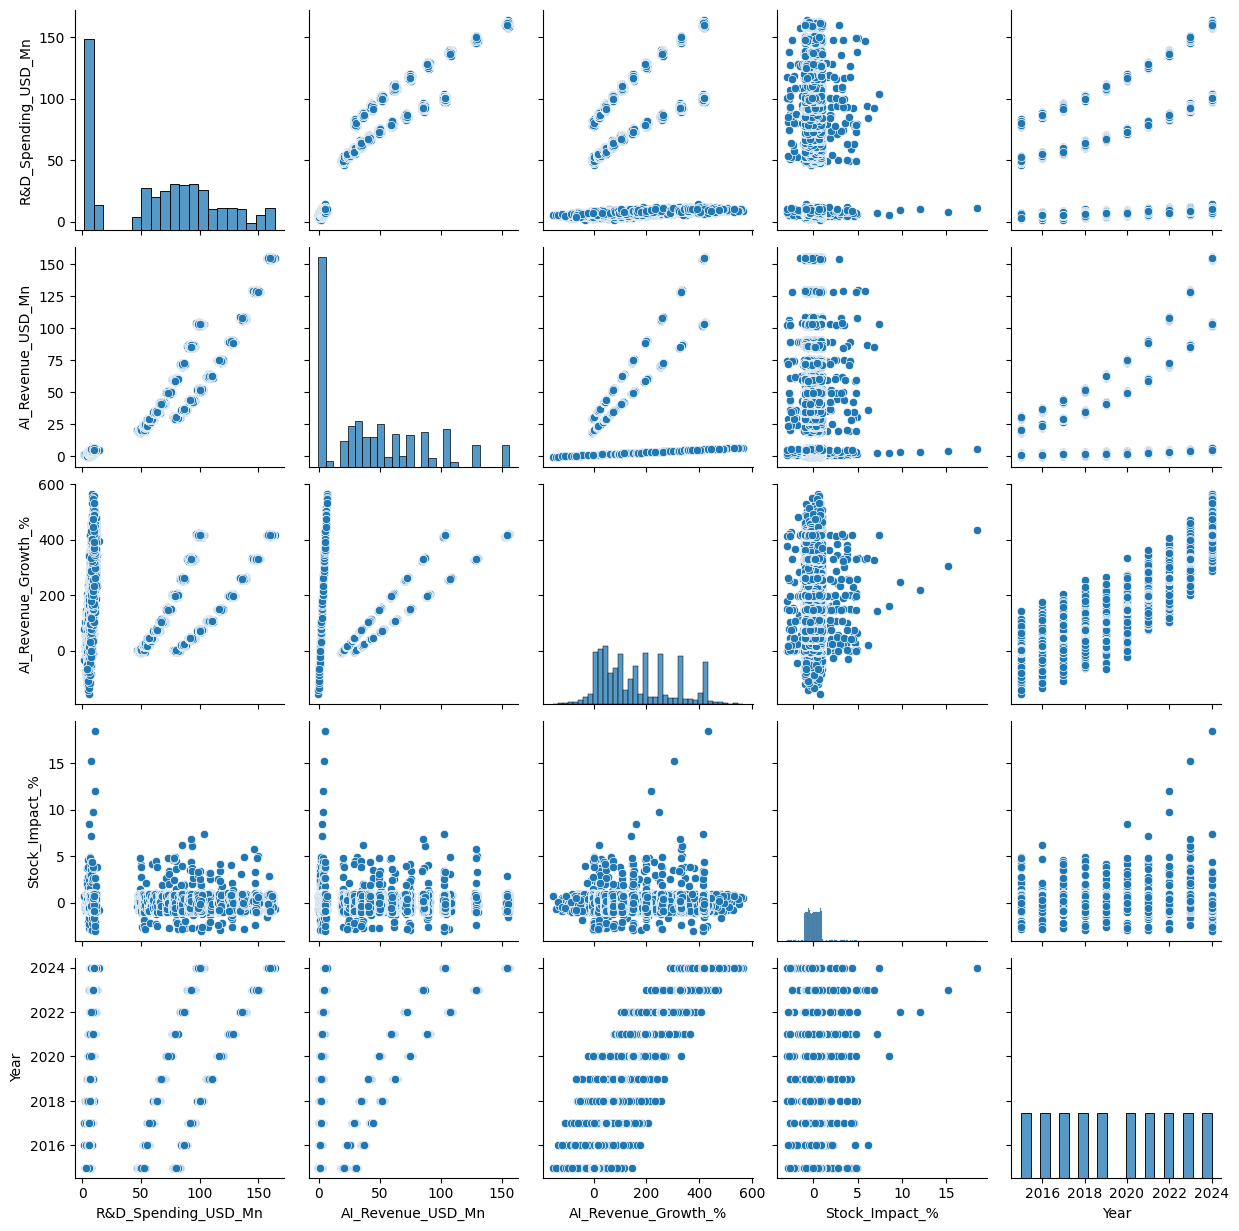

In [49]:
sns.pairplot(data)

8. Perform **event impact analysis**.  


In [50]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [51]:
data["Event"].value_counts()

Event
AI speech recognition release      37
AI Ads Optimization upgrade        32
AI partnership deal                32
AI-powered search update           32
AI Video Recommendation upgrade    29
AI ethics policy update            27
Cloud AI launch                    27
GPT-1 release                       1
GPT-2 release                       1
GPT-3 release                       1
Codex release                       1
DALL·E 2 release                    1
ChatGPT (GPT-3.5) launch            1
GPT-4 release                       1
GPT-5 release (predicted)           1
TensorFlow open-source release      1
AlphaGo beats Lee Sedol             1
BERT for Search launch              1
MUM Search Model launch             1
Bard chatbot launch                 1
Gemini AI release                   1
LLaMA 1 release                     1
LLaMA 2 release                     1
LLaMA 3 release (predicted)         1
Name: count, dtype: int64

In [52]:
data[data["Event"] == "TensorFlow open-source release"]

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3965,2015-11-09,Google,79.62,29.84,-0.53,TensorFlow open-source release,4.5,2015


In [54]:
tf = data.loc[3955:3975]
tf

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3955,2015-10-30,Google,80.33,29.87,-0.43,NaN,0.43,2015
3956,2015-10-31,Google,79.53,30.30,0.99,NaN,-0.84,2015
3957,2015-11-01,Google,80.37,29.86,-0.48,NaN,0.57,2015
3958,2015-11-02,Google,77.89,29.97,-0.10,NaN,0.76,2015
3959,2015-11-03,Google,81.00,29.43,-1.89,NaN,-0.45,2015
3960,2015-11-04,Google,80.70,29.71,-0.96,AI speech recognition release,-2.17,2015
3961,2015-11-05,Google,78.31,30.25,0.85,NaN,0.31,2015
3962,2015-11-06,Google,79.08,29.84,-0.54,NaN,-0.72,2015
3963,2015-11-07,Google,79.65,30.34,1.14,NaN,0.58,2015
3964,2015-11-08,Google,79.63,29.74,-0.86,NaN,-0.61,2015


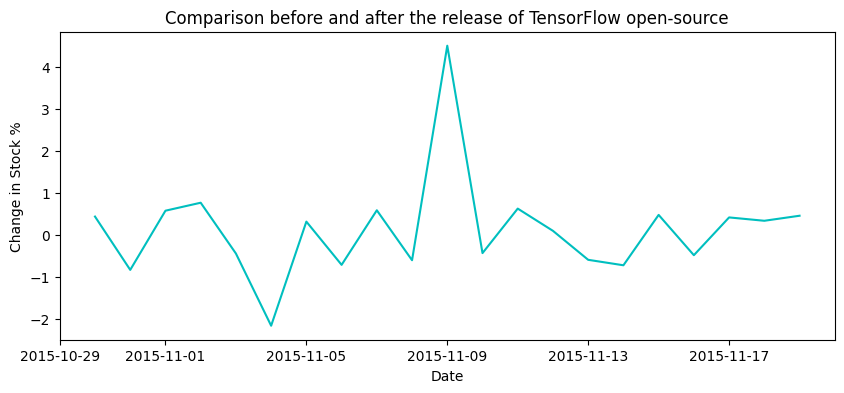

In [64]:
plt.figure(figsize=(10,4))
plt.plot( tf['Date'], tf['Stock_Impact_%'], color = 'c')
plt.title("Comparison before and after the release of TensorFlow open-source")
plt.xlabel("Date")
plt.ylabel("Change in Stock %")
plt.savefig("Figures/tf.png")
plt.show()

In [55]:
data[ data.Event == 'GPT-4 release']

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.2,2023


In [56]:
gpt4 = data.loc[ 2984 : 3004]
gpt4

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2984,2023-03-04,OpenAI,10.59,4.26,326.43,NaN,-0.28,2023
2985,2023-03-05,OpenAI,8.24,3.58,257.92,NaN,-0.48,2023
2986,2023-03-06,OpenAI,9.32,4.21,320.60,NaN,0.89,2023
2987,2023-03-07,OpenAI,8.52,4.13,313.16,NaN,-0.08,2023
2988,2023-03-08,OpenAI,8.90,3.63,263.03,NaN,-0.56,2023
2989,2023-03-09,OpenAI,8.44,4.64,363.84,NaN,0.91,2023
2990,2023-03-10,OpenAI,9.55,4.83,383.49,NaN,-0.02,2023
2991,2023-03-11,OpenAI,8.34,3.95,294.67,NaN,0.19,2023
2992,2023-03-12,OpenAI,8.71,3.57,256.88,NaN,-0.87,2023
2993,2023-03-13,OpenAI,10.61,5.19,419.06,NaN,0.53,2023


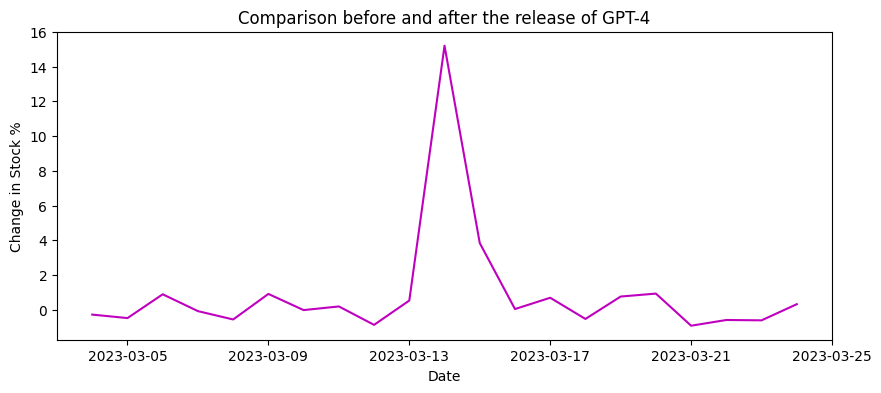

In [65]:
plt.figure(figsize = (10,4))

plt.plot( gpt4['Date'], gpt4['Stock_Impact_%'], color = 'm')

plt.title("Comparison before and after the release of GPT-4")
plt.xlabel("Date")
plt.ylabel("Change in Stock %")
plt.savefig("Figures/gpt4.png")
plt.show()

In [67]:
# Daily Average impact on the Stocks of the companies
data.groupby('Company')['Stock_Impact_%'].mean()*100

Company
Google    2.620860
Meta      0.976184
OpenAI    4.070901
Name: Stock_Impact_%, dtype: float64

In [68]:
# Daily average Expeniture R&D by the companies
data.groupby('Company')['R&D_Spending_USD_Mn'].mean()

Company
Google    115.888623
Meta       72.415294
OpenAI      7.249595
Name: R&D_Spending_USD_Mn, dtype: float64

In [69]:
# Maximun impact % on a company's stocks
data.groupby('Company')['Stock_Impact_%'].max()

Company
Google     6.2
Meta       7.4
OpenAI    18.5
Name: Stock_Impact_%, dtype: float64

9. Track **changes in stock index** with respect to year and company.


In [61]:
stocks = data.groupby(['Year', 'Company'])['Stock_Impact_%'].max()

stocks

Year  Company
2015  Google      4.96
      Meta        4.80
      OpenAI      3.92
2016  Google      6.20
      Meta        2.14
      OpenAI      4.66
2017  Google      4.42
      Meta        4.21
      OpenAI      4.63
2018  Google      1.97
      Meta        4.54
      OpenAI      4.94
2019  Google      3.20
      Meta        1.86
      OpenAI      4.20
2020  Google      4.18
      Meta        4.86
      OpenAI      8.50
2021  Google      4.10
      Meta        4.80
      OpenAI      7.20
2022  Google      4.88
      Meta        3.98
      OpenAI     12.00
2023  Google      5.80
      Meta        6.80
      OpenAI     15.20
2024  Google      2.89
      Meta        7.40
      OpenAI     18.50
Name: Stock_Impact_%, dtype: float64

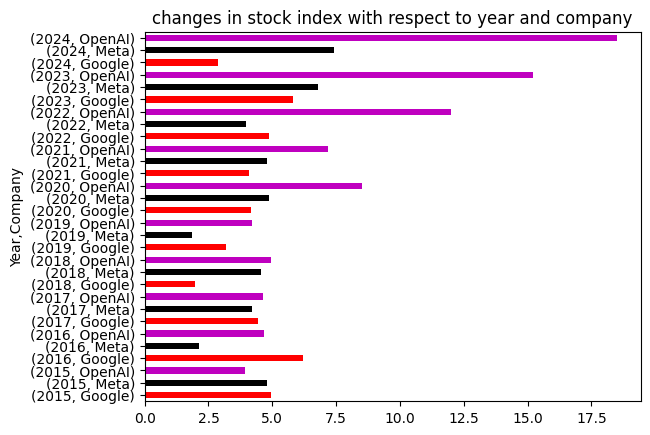

In [66]:
stocks.plot(kind = 'barh', color = ['r', 'black', 'm'])

plt.title("changes in stock index with respect to year and company")
plt.savefig("Figures/Change_stock_index_with_year_and_company.png")
plt.show()